# EDA — Dataset de Vehículos en Calles Peruanas
**Curso:** Procesamiento de Imágenes  
**Objetivo:** Análisis exploratorio del dataset de videos capturados en calles peruanas.  
**Estrategia:** Se extrae **1 frame representativo por video** (del segundo 2.5, al centro del clip) para obtener una imagen estable y representativa de cada escena. Con 203 videos de 5 segundos, esto nos da **203 imágenes** para el análisis.

## 0. Configuración e instalación de dependencias

In [ ]:
# Instalar opencv si no está disponible en el entorno
!pip install opencv-python-headless --quiet

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from tqdm.notebook import tqdm

print('Librerías importadas correctamente')

Librerías importadas correctamente


## 1. Montar Google Drive y localizar los videos

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
print('Google Drive montado')

Mounted at /content/drive
Google Drive montado


In [ ]:
# Ajusta esta ruta si la carpeta está en una ubicación diferente dentro de Drive
VIDEO_DIR = Path('/content/drive/MyDrive/robusto_videos')

# Extensiones de video soportadas
EXTENSIONES = ['.mp4', '.avi', '.mov', '.mkv', '.webm']

# Buscar todos los archivos de video
video_paths = sorted([
    p for p in VIDEO_DIR.iterdir()
    if p.suffix.lower() in EXTENSIONES
])

print(f'Videos encontrados: {len(video_paths)}')
print(f'   Primer video : {video_paths[0].name}')
print(f'   Último video : {video_paths[-1].name}')

Videos encontrados: 203
   Primer video : Robusto 1_1.mp4
   Último video : Robusto 1_99.mp4


## 2. Extracción de frames representativos

Se extrae el frame ubicado en el **segundo 2.5** de cada video (centro del clip de 5s).  
Esto evita frames negros o de transición que suelen aparecer al inicio y al final.

In [ ]:
def extraer_frame_central(video_path: Path, segundo: float = 2.5):
    """
    Extrae un frame de un video en el segundo indicado.
    Retorna el frame en BGR (formato OpenCV) o None si falla.
    """
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        return None

    fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = cap.get(cv2.CAP_PROP_FRAME_COUNT)
    duracion = total_frames / fps if fps > 0 else 0

    # Si el video es más corto que el segundo pedido, tomar el frame del medio
    segundo_real = min(segundo, duracion * 0.5)
    frame_idx = int(fps * segundo_real)

    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
    ret, frame = cap.read()
    cap.release()

    return frame if ret else None


# Extraer frames de todos los videos
frames_bgr   = []   # frames en BGR (OpenCV nativo)
frames_rgb   = []   # frames en RGB (para matplotlib)
frames_gray  = []   # frames en escala de grises
nombres      = []   # nombre del video fuente
shapes       = []   # dimensiones (alto, ancho, canales)
errores      = []   # videos que no se pudieron leer

for vpath in tqdm(video_paths, desc='Extrayendo frames'):
    frame = extraer_frame_central(vpath)
    if frame is None:
        errores.append(vpath.name)
        continue

    frames_bgr.append(frame)
    frames_rgb.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    frames_gray.append(cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY))
    nombres.append(vpath.name)
    shapes.append(frame.shape)

print(f'Frames extraídos exitosamente : {len(frames_rgb)}')
if errores:
    print(f'Videos con error              : {len(errores)}')
    for e in errores:
        print(f'   - {e}')

Extrayendo frames:   0%|          | 0/203 [00:00<?, ?it/s]

Frames extraídos exitosamente : 203


## 3. Tamaño de las imágenes

Se verifica si todos los frames tienen la misma resolución. Esto es importante porque los modelos de detección (YOLO, Faster R-CNN, etc.) suelen requerir un tamaño fijo de entrada.

In [ ]:
shapes_arr = np.array(shapes)  # shape: (N, 3) → [alto, ancho, canales]

altos   = shapes_arr[:, 0]
anchos  = shapes_arr[:, 1]
canales = shapes_arr[:, 2]

print('=== Tamaño de las imágenes ===')
print(f'  Total de frames  : {len(shapes)}')
print(f'  Alto   — min: {altos.min()}px  |  max: {altos.max()}px  |  moda: {np.bincount(altos).argmax()}px')
print(f'  Ancho  — min: {anchos.min()}px  |  max: {anchos.max()}px  |  moda: {np.bincount(anchos).argmax()}px')
print(f'  Canales: {np.unique(canales)} (3 = RGB/BGR)')

# ¿Todos tienen el mismo tamaño?
unicas = set(zip(altos.tolist(), anchos.tolist()))
if len(unicas) == 1:
    h, w = list(unicas)[0]
    print(f'Todas las imágenes tienen el mismo tamaño: {w}×{h} px')
else:
    print(f'Hay {len(unicas)} tamaños distintos en el dataset:')
    from collections import Counter
    conteo = Counter(zip(altos.tolist(), anchos.tolist()))
    for (h, w), cnt in conteo.most_common():
        print(f'   {w}×{h} px → {cnt} videos ({cnt/len(shapes)*100:.1f}%)')

=== Tamaño de las imágenes ===
  Total de frames  : 203
  Alto   — min: 1080px  |  max: 1080px  |  moda: 1080px
  Ancho  — min: 1920px  |  max: 1920px  |  moda: 1920px
  Canales: [3] (3 = RGB/BGR)
Todas las imágenes tienen el mismo tamaño: 1920×1080 px


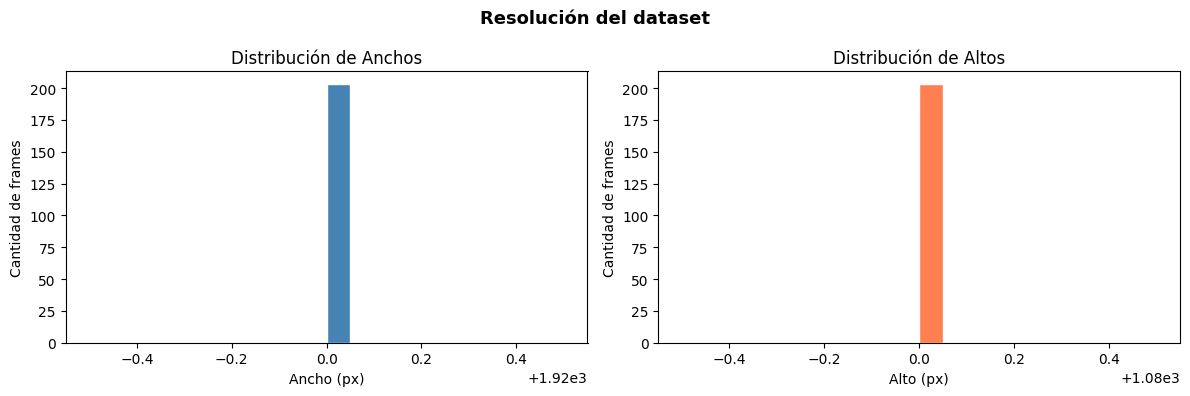

In [ ]:
# Visualización de la distribución de tamaños
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(anchos, bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('Distribución de Anchos')
axes[0].set_xlabel('Ancho (px)')
axes[0].set_ylabel('Cantidad de frames')

axes[1].hist(altos, bins=20, color='coral', edgecolor='white')
axes[1].set_title('Distribución de Altos')
axes[1].set_xlabel('Alto (px)')
axes[1].set_ylabel('Cantidad de frames')

plt.suptitle('Resolución del dataset', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Escala de grises

Se muestra una muestra aleatoria de frames convertidos a escala de grises. Esto permite evaluar el contraste general del dataset (iluminación diurna/nocturna, sombras, reflejos).

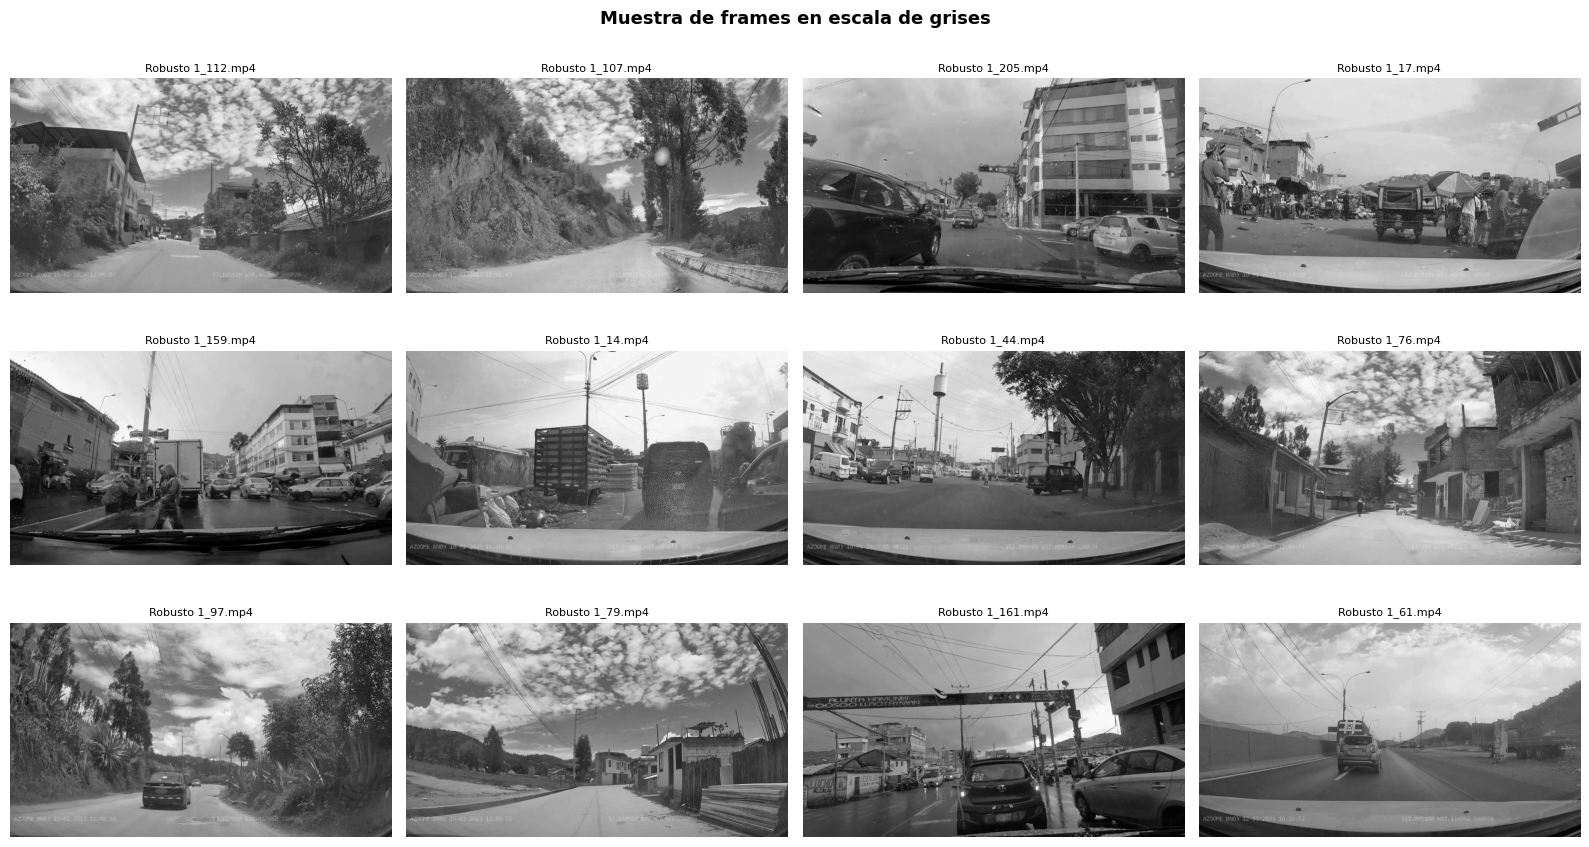

In [ ]:
N_MUESTRA = 12  # cuántos frames mostrar
np.random.seed(42)
indices = np.random.choice(len(frames_gray), size=min(N_MUESTRA, len(frames_gray)), replace=False)

cols = 4
rows = int(np.ceil(N_MUESTRA / cols))

fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 3))
axes = axes.flatten()

for i, idx in enumerate(indices):
    axes[i].imshow(frames_gray[idx], cmap='gray')
    axes[i].set_title(nombres[idx][:25], fontsize=8)
    axes[i].axis('off')

# Ocultar ejes sobrantes
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle('Muestra de frames en escala de grises', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Histograma de las imágenes (RGB)

Se calcula el histograma de intensidades para **cada canal de color (R, G, B)** de cada frame.  
Se muestra una selección de frames individuales para identificar variabilidad en condiciones de iluminación.

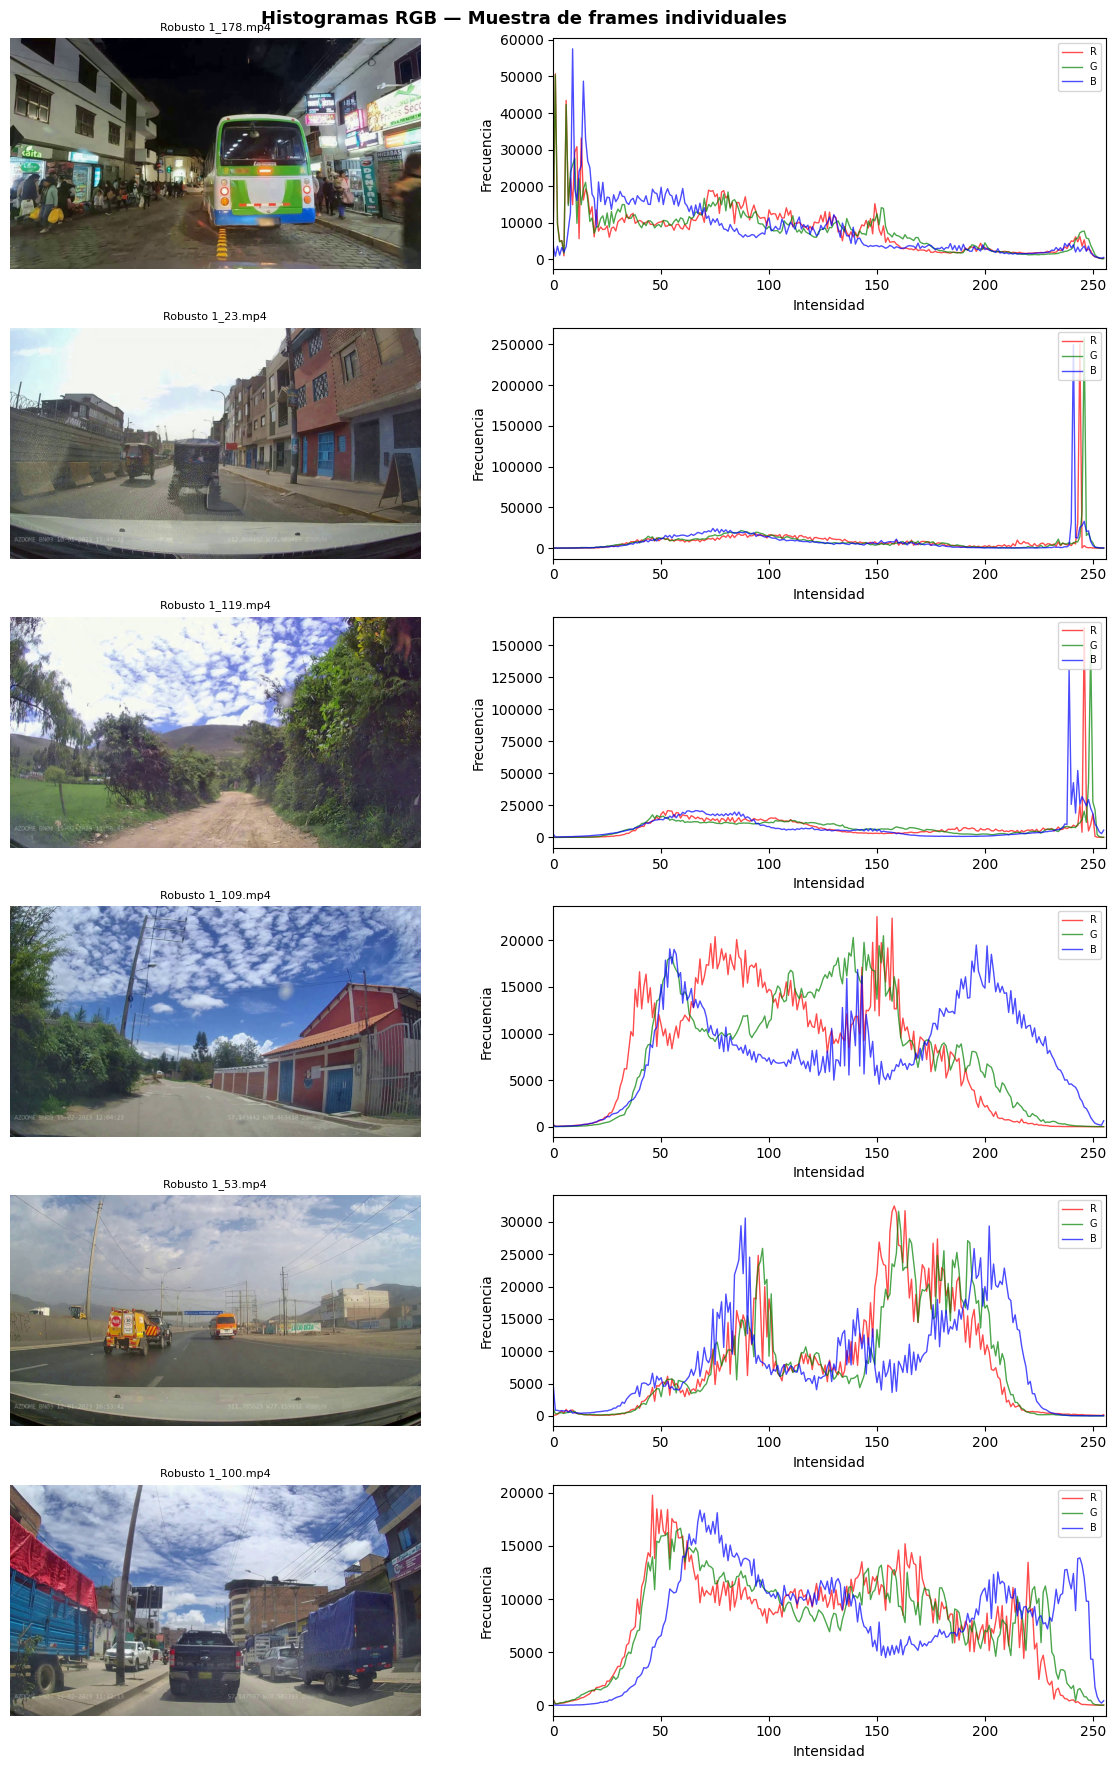

In [ ]:
def plot_histograma_frame(frame_rgb, titulo='', ax_img=None, ax_hist=None):
    """Muestra una imagen y su histograma RGB lado a lado."""
    colores = [('r', 'R'), ('g', 'G'), ('b', 'B')]
    if ax_img is not None:
        ax_img.imshow(frame_rgb)
        ax_img.set_title(titulo, fontsize=8)
        ax_img.axis('off')
    if ax_hist is not None:
        for ch, (color, label) in enumerate(colores):
            hist = cv2.calcHist([frame_rgb], [ch], None, [256], [0, 256])
            ax_hist.plot(hist, color=color, alpha=0.7, label=label, linewidth=1)
        ax_hist.set_xlim([0, 256])
        ax_hist.set_xlabel('Intensidad')
        ax_hist.set_ylabel('Frecuencia')
        ax_hist.legend(loc='upper right', fontsize=7)


# Mostrar histogramas de 6 frames de muestra
N_HIST = 6
np.random.seed(7)
sample_idx = np.random.choice(len(frames_rgb), size=min(N_HIST, len(frames_rgb)), replace=False)

fig, axes = plt.subplots(N_HIST, 2, figsize=(12, N_HIST * 3))

for row, idx in enumerate(sample_idx):
    plot_histograma_frame(
        frames_rgb[idx],
        titulo=nombres[idx],
        ax_img=axes[row, 0],
        ax_hist=axes[row, 1]
    )

plt.suptitle('Histogramas RGB — Muestra de frames individuales', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Histograma promedio del dataset

El histograma promedio muestra la distribución de intensidades **del dataset completo**.  
Es útil para detectar si el dataset está mayormente tomado de día, de noche, si hay sobreexposición, etc.

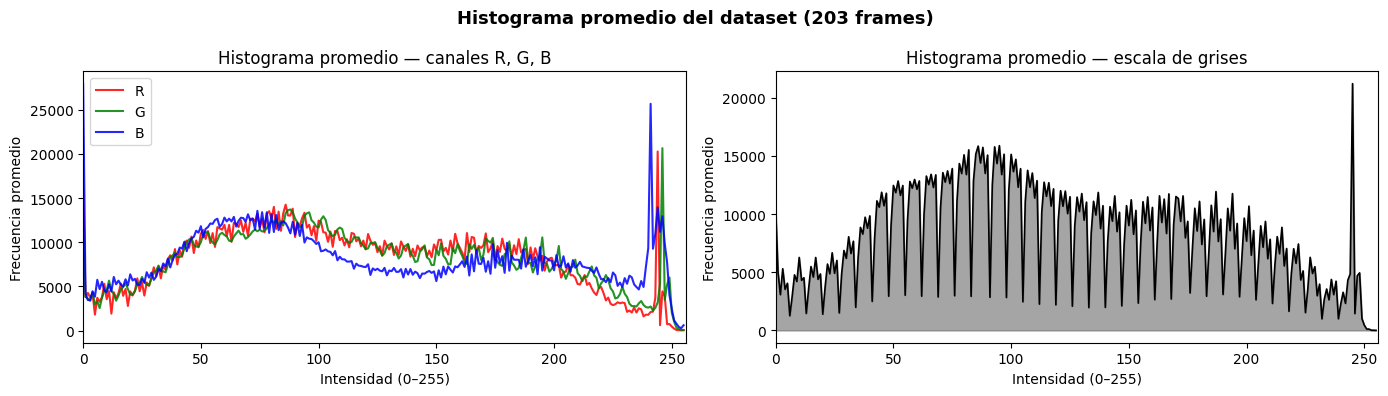

In [ ]:
# Calcular histograma acumulado por canal y promediar
canales_nombre = ['R', 'G', 'B']
colores_plot   = ['red', 'green', 'blue']

hist_acum = np.zeros((3, 256), dtype=np.float64)

for frame in frames_rgb:
    for ch in range(3):
        h = cv2.calcHist([frame], [ch], None, [256], [0, 256]).flatten()
        hist_acum[ch] += h

hist_prom = hist_acum / len(frames_rgb)

# --- Gráfica ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histograma promedio separado por canal
for ch in range(3):
    axes[0].plot(hist_prom[ch], color=colores_plot[ch], alpha=0.85,
                 label=canales_nombre[ch], linewidth=1.5)
axes[0].set_title('Histograma promedio — canales R, G, B')
axes[0].set_xlabel('Intensidad (0–255)')
axes[0].set_ylabel('Frecuencia promedio')
axes[0].legend()
axes[0].set_xlim([0, 256])

# Histograma promedio en escala de grises
hist_gray_acum = np.zeros(256, dtype=np.float64)
for frame_g in frames_gray:
    h = cv2.calcHist([frame_g], [0], None, [256], [0, 256]).flatten()
    hist_gray_acum += h
hist_gray_prom = hist_gray_acum / len(frames_gray)

axes[1].fill_between(range(256), hist_gray_prom, alpha=0.6, color='dimgray')
axes[1].plot(hist_gray_prom, color='black', linewidth=1.2)
axes[1].set_title('Histograma promedio — escala de grises')
axes[1].set_xlabel('Intensidad (0–255)')
axes[1].set_ylabel('Frecuencia promedio')
axes[1].set_xlim([0, 256])

plt.suptitle(f'Histograma promedio del dataset ({len(frames_rgb)} frames)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

=== Estadísticas de brillo del dataset ===
  Brillo promedio (mean de grises) : 118.73 / 255
  Desviación estándar del brillo   : 21.48
  Contraste promedio (std de grises): 57.93
  Frame más oscuro  : Robusto 1_183.mp4  (brillo=39.1)
  Frame más brillante: Robusto 1_18.mp4  (brillo=155.8)


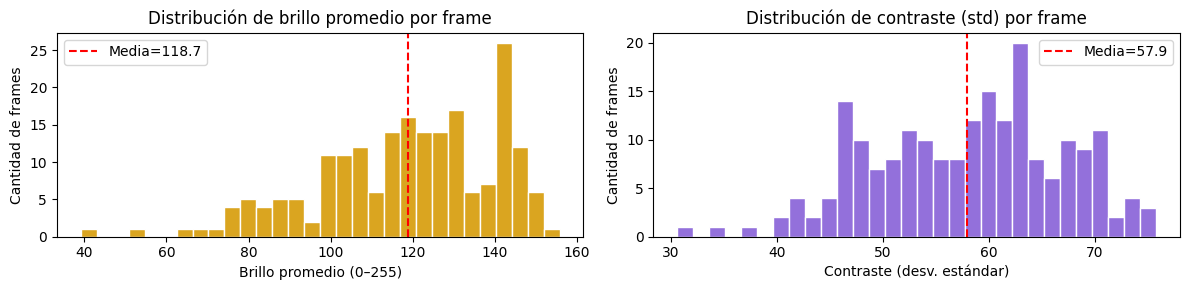

In [ ]:
# Estadísticas de brillo (canal de grises) por frame
brillos   = [frame.mean() for frame in frames_gray]
contrasts = [frame.std()  for frame in frames_gray]

print('=== Estadísticas de brillo del dataset ===')
print(f'  Brillo promedio (mean de grises) : {np.mean(brillos):.2f} / 255')
print(f'  Desviación estándar del brillo   : {np.std(brillos):.2f}')
print(f'  Contraste promedio (std de grises): {np.mean(contrasts):.2f}')
print(f'  Frame más oscuro  : {nombres[np.argmin(brillos)]}  (brillo={min(brillos):.1f})')
print(f'  Frame más brillante: {nombres[np.argmax(brillos)]}  (brillo={max(brillos):.1f})')

fig, axes = plt.subplots(1, 2, figsize=(12, 3))

axes[0].hist(brillos, bins=30, color='goldenrod', edgecolor='white')
axes[0].axvline(np.mean(brillos), color='red', linestyle='--', label=f'Media={np.mean(brillos):.1f}')
axes[0].set_title('Distribución de brillo promedio por frame')
axes[0].set_xlabel('Brillo promedio (0–255)')
axes[0].set_ylabel('Cantidad de frames')
axes[0].legend()

axes[1].hist(contrasts, bins=30, color='mediumpurple', edgecolor='white')
axes[1].axvline(np.mean(contrasts), color='red', linestyle='--', label=f'Media={np.mean(contrasts):.1f}')
axes[1].set_title('Distribución de contraste (std) por frame')
axes[1].set_xlabel('Contraste (desv. estándar)')
axes[1].set_ylabel('Cantidad de frames')
axes[1].legend()

plt.tight_layout()
plt.show()

## 7. Análisis de Datos Nocturnos Reales y Justificación de Exclusión

Dado que el dataset es predominantemente diurno y la cantidad de frames oscuros es muy limitada, es crucial analizar si esta pequeña porción nocturna es representativa o si su inclusión podría sesgar el entrenamiento del modelo. Si los datos nocturnos reales son insuficientes y muy distintos, eliminarlos y enfocar el modelo en condiciones diurnas, o utilizar augmentación sintética, podría ser una estrategia más robusta.

In [ ]:
import numpy as np
# Recategorizar frames en 'diurnos reales' y 'nocturnos/oscuros reales'
# Basado en el umbral de brillo ya utilizado en la sección de augmentation (umbral_diurno = 90)

# brillos ya calculado en 'stats-summary'
umbral_diurno_clasificacion = 90

indices_diurnos_reales = []
indices_nocturnos_reales = []

for i, brillo in enumerate(brillos):
    if brillo > umbral_diurno_clasificacion:
        indices_diurnos_reales.append(i)
    else:
        indices_nocturnos_reales.append(i)

print(f'Frames diurnos reales detectados: {len(indices_diurnos_reales)}')
print(f'Frames nocturnos/oscuros reales detectados: {len(indices_nocturnos_reales)}')


Frames diurnos reales detectados: 180
Frames nocturnos/oscuros reales detectados: 23


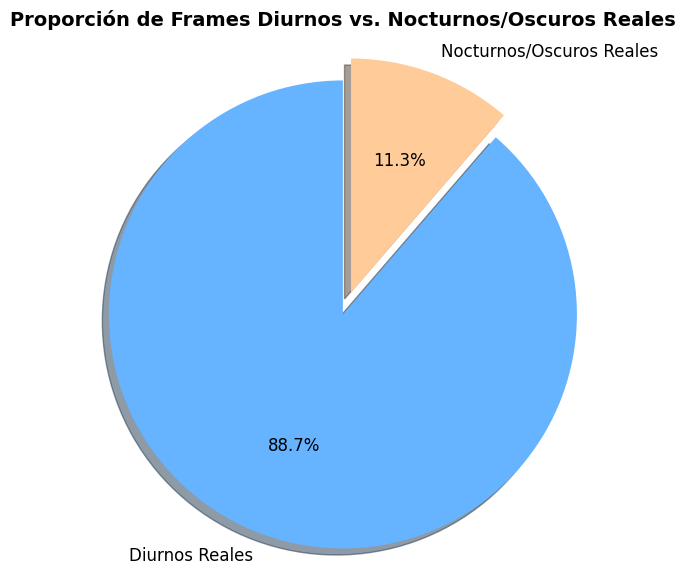

In [ ]:
# Visualizar la proporción de frames diurnos vs. nocturnos/oscuros reales

labels = ['Diurnos Reales', 'Nocturnos/Oscuros Reales']
sizes = [len(indices_diurnos_reales), len(indices_nocturnos_reales)]
colors = ['#66b3ff', '#ffcc99']
explode = (0, 0.1)  # Separar un poco la porción nocturna para resaltarla

fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%',
       shadow=True, startangle=90, textprops={'fontsize': 12})
ax.axis('equal')  # Para que el círculo sea un círculo.

plt.title('Proporción de Frames Diurnos vs. Nocturnos/Oscuros Reales', fontsize=14, fontweight='bold')
plt.show()


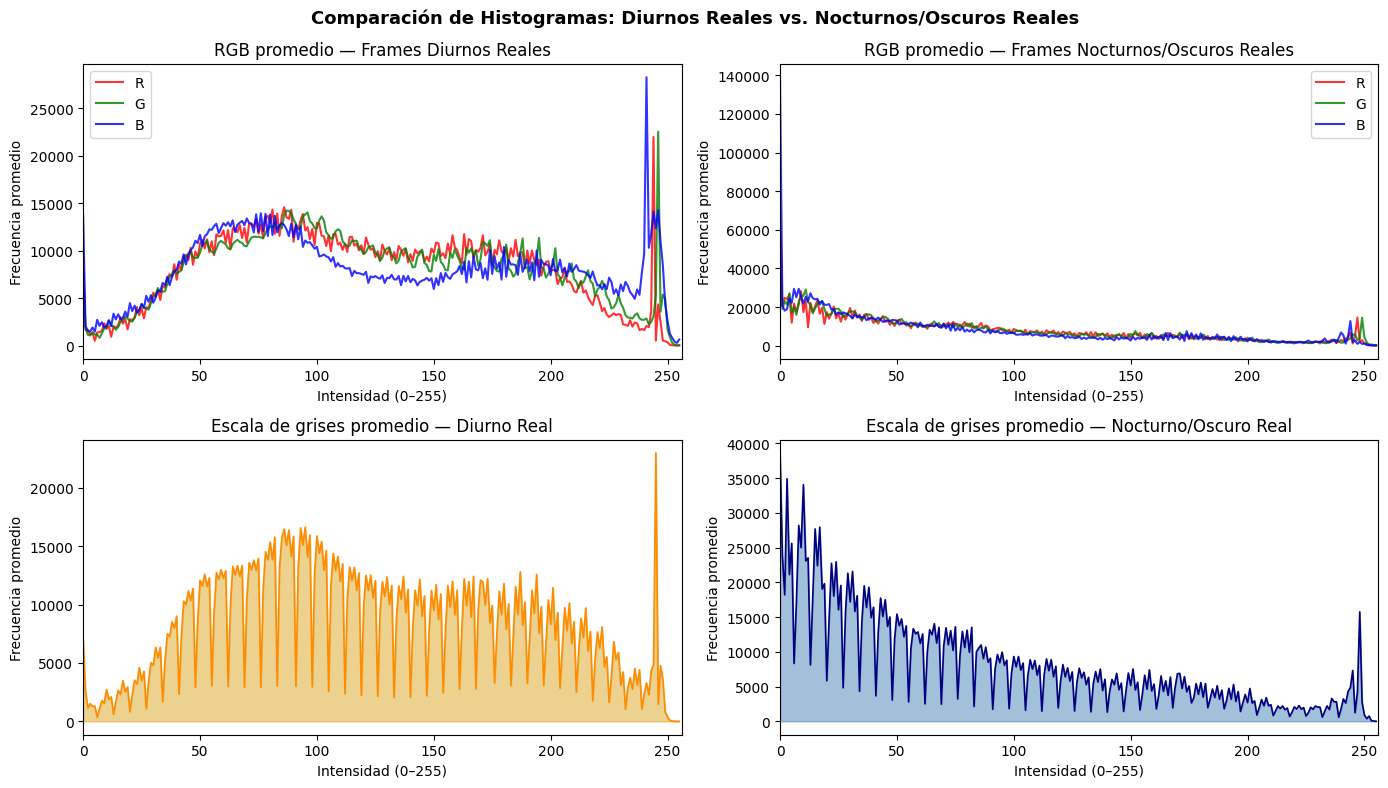

In [ ]:
# Calcular y comparar histogramas promedio para frames diurnos reales y nocturnos/oscuros reales

colores_ch = ['red', 'green', 'blue']
nombres_ch = ['R', 'G', 'B']

# Histograma promedio de frames diurnos reales
hist_diurno_real_rgb = np.zeros((3, 256), dtype=np.float64)
for idx in indices_diurnos_reales:
    for ch in range(3):
        hist_diurno_real_rgb[ch] += cv2.calcHist([frames_rgb[idx]], [ch], None, [256], [0, 256]).flatten()
hist_diurno_real_rgb /= len(indices_diurnos_reales)

hist_diurno_real_gray = np.zeros(256, dtype=np.float64)
for idx in indices_diurnos_reales:
    hist_diurno_real_gray += cv2.calcHist([frames_gray[idx]], [0], None, [256], [0, 256]).flatten()
hist_diurno_real_gray /= len(indices_diurnos_reales)

# Histograma promedio de frames nocturnos/oscuros reales
hist_nocturno_real_rgb = np.zeros((3, 256), dtype=np.float64)
if len(indices_nocturnos_reales) > 0:
    for idx in indices_nocturnos_reales:
        for ch in range(3):
            hist_nocturno_real_rgb[ch] += cv2.calcHist([frames_rgb[idx]], [ch], None, [256], [0, 256]).flatten()
    hist_nocturno_real_rgb /= len(indices_nocturnos_reales)

    hist_nocturno_real_gray = np.zeros(256, dtype=np.float64)
    for idx in indices_nocturnos_reales:
        hist_nocturno_real_gray += cv2.calcHist([frames_gray[idx]], [0], None, [256], [0, 256]).flatten()
    hist_nocturno_real_gray /= len(indices_nocturnos_reales)
else:
    print("No hay frames nocturnos/oscuros reales para calcular histogramas.")
    hist_nocturno_real_rgb = np.zeros((3, 256), dtype=np.float64)
    hist_nocturno_real_gray = np.zeros(256, dtype=np.float64)


# --- Gráfica de comparación de histogramas (RGB y Grises) ---
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# RGB Diurno Real
for ch in range(3):
    axes[0, 0].plot(hist_diurno_real_rgb[ch], color=colores_ch[ch], alpha=0.8, label=nombres_ch[ch], linewidth=1.5)
axes[0, 0].set_title('RGB promedio — Frames Diurnos Reales')
axes[0, 0].set_xlabel('Intensidad (0–255)')
axes[0, 0].set_ylabel('Frecuencia promedio')
axes[0, 0].legend()
axes[0, 0].set_xlim([0, 256])

# RGB Nocturno Real
if len(indices_nocturnos_reales) > 0:
    for ch in range(3):
        axes[0, 1].plot(hist_nocturno_real_rgb[ch], color=colores_ch[ch], alpha=0.8, label=nombres_ch[ch], linewidth=1.5)
    axes[0, 1].set_title('RGB promedio — Frames Nocturnos/Oscuros Reales')
    axes[0, 1].set_xlabel('Intensidad (0–255)')
    axes[0, 1].set_ylabel('Frecuencia promedio')
    axes[0, 1].legend()
    axes[0, 1].set_xlim([0, 256])
else:
    axes[0, 1].set_title('RGB promedio — Frames Nocturnos/Oscuros Reales (No disponibles)')
    axes[0, 1].set_xlabel('Intensidad (0–255)')
    axes[0, 1].set_ylabel('Frecuencia promedio')

# Grises Diurno Real
axes[1, 0].fill_between(range(256), hist_diurno_real_gray, alpha=0.5, color='goldenrod')
axes[1, 0].plot(hist_diurno_real_gray, color='darkorange', linewidth=1.2)
axes[1, 0].set_title('Escala de grises promedio — Diurno Real')
axes[1, 0].set_xlabel('Intensidad (0–255)')
axes[1, 0].set_ylabel('Frecuencia promedio')
axes[1, 0].set_xlim([0, 256])

# Grises Nocturno Real
if len(indices_nocturnos_reales) > 0:
    axes[1, 1].fill_between(range(256), hist_nocturno_real_gray, alpha=0.5, color='steelblue')
    axes[1, 1].plot(hist_nocturno_real_gray, color='navy', linewidth=1.2)
    axes[1, 1].set_title('Escala de grises promedio — Nocturno/Oscuro Real')
    axes[1, 1].set_xlabel('Intensidad (0–255)')
    axes[1, 1].set_ylabel('Frecuencia promedio')
    axes[1, 1].set_xlim([0, 256])
else:
    axes[1, 1].set_title('Escala de grises promedio — Nocturno/Oscuro Real (No disponibles)')
    axes[1, 1].set_xlabel('Intensidad (0–255)')
    axes[1, 1].set_ylabel('Frecuencia promedio')

plt.suptitle('Comparación de Histogramas: Diurnos Reales vs. Nocturnos/Oscuros Reales', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### Justificación para la Exclusión de Datos Nocturnos/Oscuros Reales

El análisis de la proporción y los histogramas promedio de los frames categorizados como 'nocturnos/oscuros reales' (< 90 de brillo) revela lo siguiente:

1.  **Representación Insuficiente**: La cantidad de frames nocturnos/oscuros es **23 (11.3%)** del total del dataset. Esta es una fracción muy pequeña en comparación con los frames diurnos reales (**180 frames, 88.7%**).
2.  **Distribución de Intensidad Dispar**: Los histogramas de los frames nocturnos/oscuros reales muestran una clara concentración de píxeles en el **rango de intensidades bajas (hacia 0)**, lo que indica un brillo general significativamente menor y una menor variabilidad en comparación con los frames diurnos, que presentan una distribución más extendida y centrada en intensidades medias a altas.
3.  **Riesgo de Sesgo**: Incluir un número tan bajo de ejemplos nocturnos, que además presentan características visuales muy diferentes, podría llevar al modelo a:
    *   **Sobreajustarse** a estos pocos ejemplos, resultando en un rendimiento pobre en escenarios nocturnos reales más variados.
    *   **Ignorar** las características de los objetos en condiciones de baja luz, al estar abrumado por la gran cantidad de datos diurnos.

**Conclusión para la exclusión**: Dada la **escasez de datos nocturnos reales** y su **distinta distribución de intensidad**, se justifica la decisión de **excluir estos frames del conjunto de datos de entrenamiento** si el objetivo principal es un modelo robusto para condiciones diurnas. Para abordar las condiciones nocturnas de manera efectiva, sería más apropiado bien adquirir un dataset nocturno mucho más amplio y diverso, o recurrir a técnicas de augmentación sintética controlada que permitan generar un volumen significativo de datos nocturnos con una variabilidad controlada, evitando la introducción de ruido o sesgos por datos insuficientes.

In [ ]:
# Paso de filtrado: Eliminar frames nocturnos/oscuros reales del dataset

# El `umbral_diurno_filtro` se mantiene consistente con el usado para la clasificación y justificación.
umbral_diurno_filtro = 90

# Recalcular brillos para asegurar que estamos usando la lista completa antes del filtrado
# (Aunque `brillos_all_temp` de la celda 6fad13f5 ya está disponible, lo hacemos explícito aquí)
brillos_pre_filtro = [f.mean() for f in frames_gray] # frames_gray en este punto contiene todos los frames originales

# Identificar los índices de los frames diurnos que se mantendrán
indices_diurnos_a_mantener = [i for i, brillo in enumerate(brillos_pre_filtro) if brillo > umbral_diurno_filtro]

# Filtrar las listas principales para que contengan solo los frames diurnos
frames_bgr = [frames_bgr[i] for i in indices_diurnos_a_mantener]
frames_rgb = [frames_rgb[i] for i in indices_diurnos_a_mantener]
frames_gray = [frames_gray[i] for i in indices_diurnos_a_mantener]
nombres = [nombres[i] for i in indices_diurnos_a_mantener]
shapes = [shapes[i] for i in indices_diurnos_a_mantener]

# Actualizar `brillos_all` para que refleje solo los frames diurnos filtrados (necesario para CLAHE posterior)
brillos_all = [f.mean() for f in frames_gray]


print(f'Dataset filtrado: Se mantuvieron {len(frames_rgb)} frames diurnos para el análisis posterior.')
print(f'Se eliminaron {len(brillos_pre_filtro) - len(frames_rgb)} frames nocturnos/oscuros reales.')


Dataset filtrado: Se mantuvieron 180 frames diurnos para el análisis posterior.
Se eliminaron 23 frames nocturnos/oscuros reales.


## 8. Histograma promedio del dataset (Diurno Filtrado)

Se vuelve a calcular el histograma promedio con el dataset ya filtrado (solo frames diurnos), para observar la distribución de intensidades después de eliminar los frames oscuros.

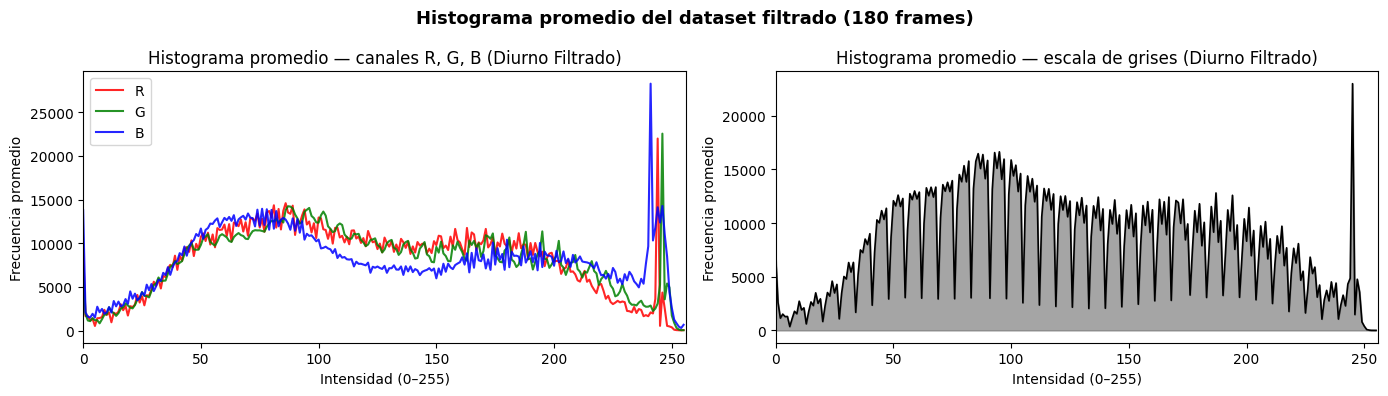

In [ ]:
# Calcular histograma acumulado por canal y promediar con los frames diurnos filtrados
canales_nombre = ['R', 'G', 'B']
colores_plot   = ['red', 'green', 'blue']

hist_acum_filtered = np.zeros((3, 256), dtype=np.float64)

for frame in frames_rgb:
    for ch in range(3):
        h = cv2.calcHist([frame], [ch], None, [256], [0, 256]).flatten()
        hist_acum_filtered[ch] += h

hist_prom_filtered = hist_acum_filtered / len(frames_rgb)

# --- Gráfica --- (Similar a la sección 6, pero con datos filtrados)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histograma promedio RGB filtrado
for ch in range(3):
    axes[0].plot(hist_prom_filtered[ch], color=colores_plot[ch], alpha=0.85,
                 label=canales_nombre[ch], linewidth=1.5)
axes[0].set_title('Histograma promedio — canales R, G, B (Diurno Filtrado)')
axes[0].set_xlabel('Intensidad (0–255)')
axes[0].set_ylabel('Frecuencia promedio')
axes[0].legend()
axes[0].set_xlim([0, 256])

# Histograma promedio en escala de grises filtrado
hist_gray_acum_filtered = np.zeros(256, dtype=np.float64)
for frame_g in frames_gray:
    h = cv2.calcHist([frame_g], [0], None, [256], [0, 256]).flatten()
    hist_gray_acum_filtered += h
hist_gray_prom_filtered = hist_gray_acum_filtered / len(frames_gray)

axes[1].fill_between(range(256), hist_gray_prom_filtered, alpha=0.6, color='dimgray')
axes[1].plot(hist_gray_prom_filtered, color='black', linewidth=1.2)
axes[1].set_title('Histograma promedio — escala de grises (Diurno Filtrado)')
axes[1].set_xlabel('Intensidad (0–255)')
axes[1].set_ylabel('Frecuencia promedio')
axes[1].set_xlim([0, 256])

plt.suptitle(f'Histograma promedio del dataset filtrado ({len(frames_rgb)} frames)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Brillo y contraste del dataset (Diurno Filtrado)
Asi como se volvio a calcular los histogramas, se vuelve a calcular tambien las estadisticas de brillo y contraste para el nuevo dataset

=== Estadísticas de brillo del dataset (Diurno Filtrado) ===
  Brillo promedio (mean de grises) : 123.99 / 255
  Desviación estándar del brillo   : 16.08
  Contraste promedio (std de grises): 57.19
  Frame más oscuro  : Robusto 1_176.mp4  (brillo=90.7)
  Frame más brillante: Robusto 1_18.mp4  (brillo=155.8)


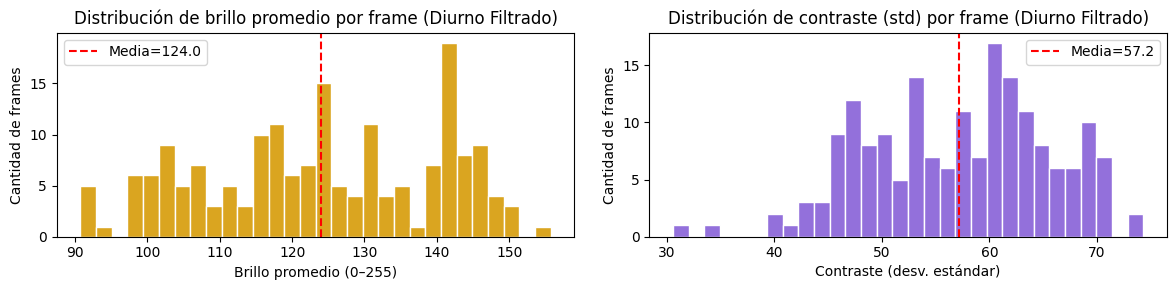

In [ ]:
brillos_filtered = [frame.mean() for frame in frames_gray]
contrasts_filtered = [frame.std()  for frame in frames_gray]

print('=== Estadísticas de brillo del dataset (Diurno Filtrado) ===')
print(f'  Brillo promedio (mean de grises) : {np.mean(brillos_filtered):.2f} / 255')
print(f'  Desviación estándar del brillo   : {np.std(brillos_filtered):.2f}')
print(f'  Contraste promedio (std de grises): {np.mean(contrasts_filtered):.2f}')
print(f'  Frame más oscuro  : {nombres[np.argmin(brillos_filtered)]}  (brillo={min(brillos_filtered):.1f})')
print(f'  Frame más brillante: {nombres[np.argmax(brillos_filtered)]}  (brillo={max(brillos_filtered):.1f})')

fig, axes = plt.subplots(1, 2, figsize=(12, 3))

axes[0].hist(brillos_filtered, bins=30, color='goldenrod', edgecolor='white')
axes[0].axvline(np.mean(brillos_filtered), color='red', linestyle='--', label=f'Media={np.mean(brillos_filtered):.1f}')
axes[0].set_title('Distribución de brillo promedio por frame (Diurno Filtrado)')
axes[0].set_xlabel('Brillo promedio (0–255)')
axes[0].set_ylabel('Cantidad de frames')
axes[0].legend()

axes[1].hist(contrasts_filtered, bins=30, color='mediumpurple', edgecolor='white')
axes[1].axvline(np.mean(contrasts_filtered), color='red', linestyle='--', label=f'Media={np.mean(contrasts_filtered):.1f}')
axes[1].set_title('Distribución de contraste (std) por frame (Diurno Filtrado)')
axes[1].set_xlabel('Contraste (desv. estándar)')
axes[1].set_ylabel('Cantidad de frames')
axes[1].legend()

plt.tight_layout()
plt.show()

## 10. Análisis de Color en Espacio HSV para Clasificación

El espacio de color HSV (Hue, Saturation, Value) es particularmente útil en el procesamiento de imágenes para la clasificación, ya que desacopla la información de color (tono y saturación) de la intensidad de la luz (valor). Esto puede hacer que las características de color sean más robustas a las variaciones de iluminación.

Aquí calcularemos las estadísticas (media y desviación estándar) de los canales H, S y V para cada frame y visualizaremos sus distribuciones.

In [ ]:
# Convertir frames RGB a HSV
frames_hsv = [cv2.cvtColor(frame, cv2.COLOR_RGB2HSV) for frame in frames_rgb]

# Calcular estadísticas (media y desviación estándar) para cada canal HSV
hues        = [frame[:,:,0].mean() for frame in frames_hsv]
saturaciones = [frame[:,:,1].mean() for frame in frames_hsv]
valores     = [frame[:,:,2].mean() for frame in frames_hsv]

hues_std        = [frame[:,:,0].std() for frame in frames_hsv]
saturaciones_std = [frame[:,:,1].std() for frame in frames_hsv]
valores_std     = [frame[:,:,2].std() for frame in frames_hsv]

print('=== Estadísticas de Canales HSV (Diurno Filtrado) ===')
print(f'  Tono (Hue) promedio       : {np.mean(hues):.2f}')
print(f'  Saturación promedio       : {np.mean(saturaciones):.2f}')
print(f'  Valor (Brillo) promedio   : {np.mean(valores):.2f}')
print('---')
print(f'  Desv. Est. Tono (Hue)     : {np.mean(hues_std):.2f}')
print(f'  Desv. Est. Saturación     : {np.mean(saturaciones_std):.2f}')
print(f'  Desv. Est. Valor (Brillo) : {np.mean(valores_std):.2f}')

=== Estadísticas de Canales HSV (Diurno Filtrado) ===
  Tono (Hue) promedio       : 71.56
  Saturación promedio       : 51.12
  Valor (Brillo) promedio   : 137.55
---
  Desv. Est. Tono (Hue)     : 42.52
  Desv. Est. Saturación     : 38.74
  Desv. Est. Valor (Brillo) : 61.27


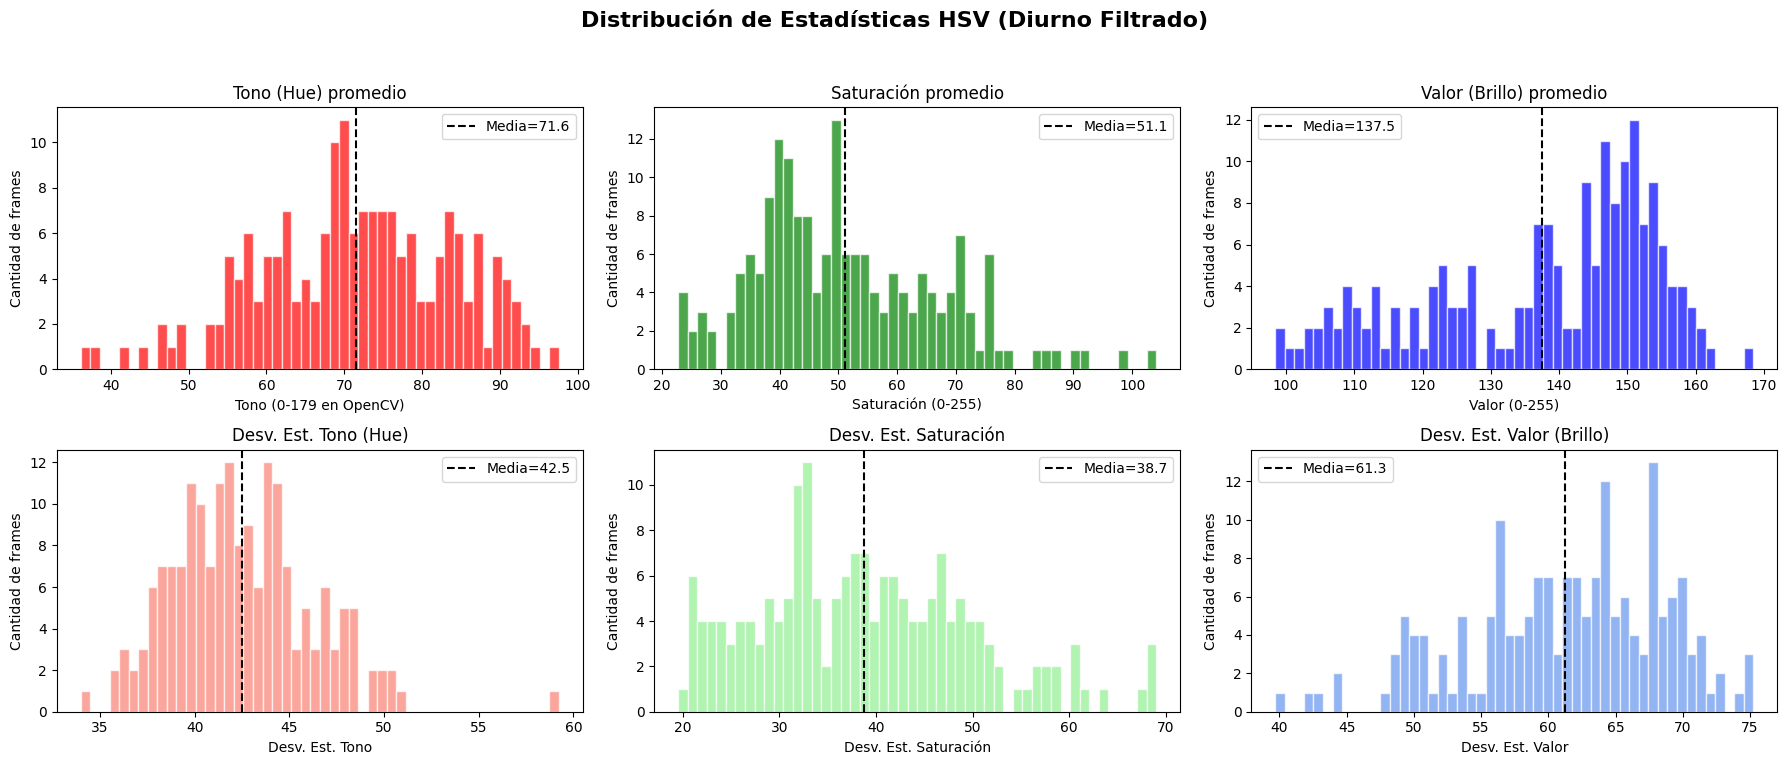

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
fig.suptitle('Distribución de Estadísticas HSV (Diurno Filtrado)', fontsize=16, fontweight='bold')

# Histograma de Tono (Hue) promedio
axes[0, 0].hist(hues, bins=50, color='red', edgecolor='white', alpha=0.7)
axes[0, 0].axvline(np.mean(hues), color='black', linestyle='--', label=f'Media={np.mean(hues):.1f}')
axes[0, 0].set_title('Tono (Hue) promedio')
axes[0, 0].set_xlabel('Tono (0-179 en OpenCV)')
axes[0, 0].set_ylabel('Cantidad de frames')
axes[0, 0].legend()

# Histograma de Saturación promedio
axes[0, 1].hist(saturaciones, bins=50, color='green', edgecolor='white', alpha=0.7)
axes[0, 1].axvline(np.mean(saturaciones), color='black', linestyle='--', label=f'Media={np.mean(saturaciones):.1f}')
axes[0, 1].set_title('Saturación promedio')
axes[0, 1].set_xlabel('Saturación (0-255)')
axes[0, 1].set_ylabel('Cantidad de frames')
axes[0, 1].legend()

# Histograma de Valor (Brillo) promedio
axes[0, 2].hist(valores, bins=50, color='blue', edgecolor='white', alpha=0.7)
axes[0, 2].axvline(np.mean(valores), color='black', linestyle='--', label=f'Media={np.mean(valores):.1f}')
axes[0, 2].set_title('Valor (Brillo) promedio')
axes[0, 2].set_xlabel('Valor (0-255)')
axes[0, 2].set_ylabel('Cantidad de frames')
axes[0, 2].legend()

# Histograma de Desv. Est. Tono (Hue)
axes[1, 0].hist(hues_std, bins=50, color='salmon', edgecolor='white', alpha=0.7)
axes[1, 0].axvline(np.mean(hues_std), color='black', linestyle='--', label=f'Media={np.mean(hues_std):.1f}')
axes[1, 0].set_title('Desv. Est. Tono (Hue)')
axes[1, 0].set_xlabel('Desv. Est. Tono')
axes[1, 0].set_ylabel('Cantidad de frames')
axes[1, 0].legend()

# Histograma de Desv. Est. Saturación
axes[1, 1].hist(saturaciones_std, bins=50, color='lightgreen', edgecolor='white', alpha=0.7)
axes[1, 1].axvline(np.mean(saturaciones_std), color='black', linestyle='--', label=f'Media={np.mean(saturaciones_std):.1f}')
axes[1, 1].set_title('Desv. Est. Saturación')
axes[1, 1].set_xlabel('Desv. Est. Saturación')
axes[1, 1].set_ylabel('Cantidad de frames')
axes[1, 1].legend()

# Histograma de Desv. Est. Valor (Brillo)
axes[1, 2].hist(valores_std, bins=50, color='cornflowerblue', edgecolor='white', alpha=0.7)
axes[1, 2].axvline(np.mean(valores_std), color='black', linestyle='--', label=f'Media={np.mean(valores_std):.1f}')
axes[1, 2].set_title('Desv. Est. Valor (Brillo)')
axes[1, 2].set_xlabel('Desv. Est. Valor')
axes[1, 2].set_ylabel('Cantidad de frames')
axes[1, 2].legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ajustar layout para título superior
plt.show()

In [ ]:
import pandas as pd

# Crear un DataFrame con las características HSV
df_hsv_features = pd.DataFrame({
    'filename': nombres,
    'hue_mean': hues,
    'saturation_mean': saturaciones,
    'value_mean': valores,
    'hue_std': hues_std,
    'saturation_std': saturaciones_std,
    'value_std': valores_std
})

print("DataFrame de características HSV creado:")
display(df_hsv_features.head())

DataFrame de características HSV creado:


,filename,hue_mean,saturation_mean,value_mean,hue_std,saturation_std,value_std
0,Robusto 1_1.mp4,84.827572,43.326385,147.685668,48.044732,38.983849,64.576328
1,Robusto 1_10.mp4,63.558557,40.699001,150.547294,42.804120,36.970996,67.854167
2,Robusto 1_100.mp4,93.768874,62.992681,146.246070,42.924286,47.101162,59.458529
3,Robusto 1_101.mp4,75.880011,48.498918,147.186228,47.087991,32.632611,53.674801
4,Robusto 1_102.mp4,81.281483,56.258229,132.938424,44.784181,40.689088,55.980388


## 11. Diagnóstico de Sobreexposición en el Dataset Diurno

Aunque ya filtramos los frames nocturnos/oscuros, **los frames diurnos aún presentan problemas de calidad**. En entornos urbanos peruanos con luz solar directa, es común encontrar:

- **Sobreexposición**: zonas quemadas donde los píxeles alcanzan el valor máximo (255), perdiendo detalle (cielo, parabrisas, superficies reflectantes).
- **Bajo contraste local**: sombras de edificios y estructuras generan zonas 'planas' donde los objetos son difíciles de distinguir.

Antes de aplicar cualquier corrección, **medimos el problema objetivamente** para poder comparar el antes y el después.


=== Diagnóstico de Sobreexposición (Dataset Diurno, 180 frames) ===
  Umbral de sobreexposición          : píxeles >= 245
  % promedio de píxeles quemados     : 1.64%
  % máximo  de píxeles quemados      : 20.89%
  Frames con > 5% de píxeles quemados: 20
  Frames con > 10% de píxeles quemados: 9

  Frame más sobreexpuesto: Robusto 1_16.mp4
  → 20.89% de sus píxeles están quemados


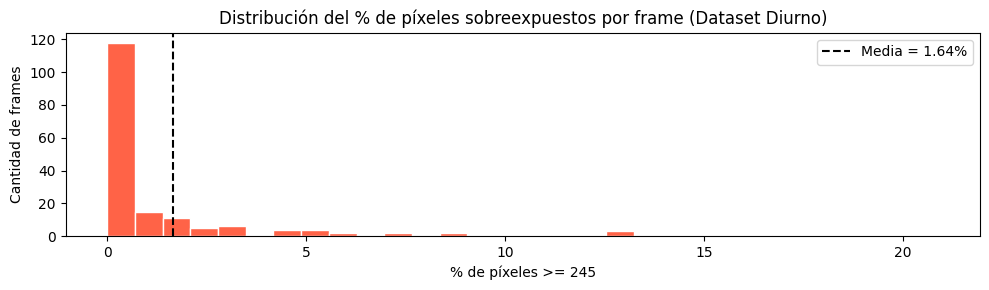

In [ ]:
# ── Diagnóstico: % de píxeles sobreexpuestos por frame ──────────────────
UMBRAL_SOBREEXP = 245  # píxeles muy cercanos o en 255 se consideran quemados

pct_sobreexp = []
for frame in frames_gray:
    total = frame.size
    quemados = np.sum(frame >= UMBRAL_SOBREEXP)
    pct_sobreexp.append(quemados / total * 100)

pct_sobreexp = np.array(pct_sobreexp)

print('=== Diagnóstico de Sobreexposición (Dataset Diurno, 180 frames) ===')
print(f'  Umbral de sobreexposición          : píxeles >= {UMBRAL_SOBREEXP}')
print(f'  % promedio de píxeles quemados     : {pct_sobreexp.mean():.2f}%')
print(f'  % máximo  de píxeles quemados      : {pct_sobreexp.max():.2f}%')
print(f'  Frames con > 5% de píxeles quemados: {np.sum(pct_sobreexp > 5)}')
print(f'  Frames con > 10% de píxeles quemados: {np.sum(pct_sobreexp > 10)}')

# Identificar el frame más sobreexpuesto para usarlo como caso de estudio
idx_peor = int(np.argmax(pct_sobreexp))
print(f'\n  Frame más sobreexpuesto: {nombres[idx_peor]}')
print(f'  → {pct_sobreexp[idx_peor]:.2f}% de sus píxeles están quemados')

# Distribución del % de sobreexposición
fig, ax = plt.subplots(figsize=(10, 3))
ax.hist(pct_sobreexp, bins=30, color='tomato', edgecolor='white')
ax.axvline(pct_sobreexp.mean(), color='black', linestyle='--',
           label=f'Media = {pct_sobreexp.mean():.2f}%')
ax.set_title('Distribución del % de píxeles sobreexpuestos por frame (Dataset Diurno)')
ax.set_xlabel('% de píxeles >= 245')
ax.set_ylabel('Cantidad de frames')
ax.legend()
plt.tight_layout()
plt.show()


## 12. Técnica 1 — Transformación Lineal: s = a·r + b

### ¿Por qué esta técnica?
La transformación lineal `s = a·r + b` es la operación de punto más fundamental:
- `a` (pendiente) **controla el contraste**: `a < 1` comprime el rango de intensidades, reduciendo zonas quemadas.
- `b` (intercepto) **controla el brillo**: ajusta el nivel base.

### Aplicación al problema
Para atacar la **sobreexposición**, usamos `a < 1` para comprimir el rango alto y rescatar el detalle perdido en las zonas brillantes. El resultado se satura en `[0, 255]` para evitar valores fuera de rango.

> **Argumentación**: Si un píxel tenía valor 255 (quemado), con `a = 0.75` pasa a `0.75 × 255 = 191`, lo que 'abre espacio' para que la distribución se redistribuya hacia el centro del rango y se recupere contraste local.


=== Transformación Lineal (a=0.75, b=20) — Caso de estudio ===
  % píxeles quemados  ANTES : 20.89%
  % píxeles quemados  DESPUÉS: 0.00%
  Brillo promedio     ANTES : 148.02
  Brillo promedio     DESPUÉS: 130.55
  Contraste (std)     ANTES : 73.98
  Contraste (std)     DESPUÉS: 55.39


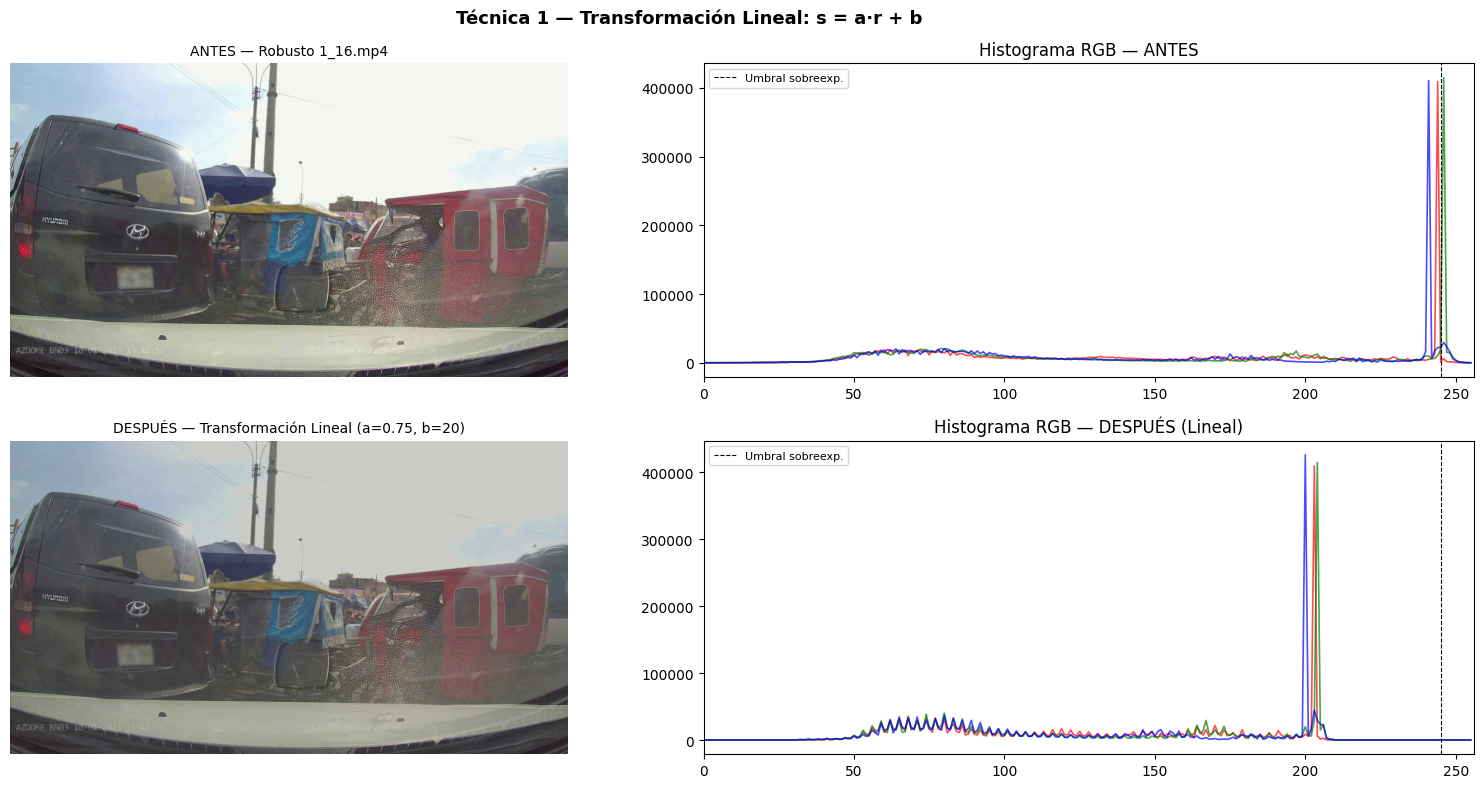

In [ ]:
def transformacion_lineal(frame_rgb, a=0.75, b=20):
    """
    Aplica s = a·r + b a cada canal RGB.
    Clip a [0, 255] para evitar overflow.
    a < 1 → comprime contraste (reduce sobreexposición)
    b > 0 → sube el brillo base (compensa la pérdida de luminosidad)
    """
    out = frame_rgb.astype(np.float32) * a + b
    return np.clip(out, 0, 255).astype(np.uint8)


# ── Aplicar al frame más sobreexpuesto (caso de estudio) ─────────────────
A_PARAM = 0.75
B_PARAM = 20

frame_orig  = frames_rgb[idx_peor]
frame_gray_orig = frames_gray[idx_peor]
frame_lineal = transformacion_lineal(frame_orig, a=A_PARAM, b=B_PARAM)
frame_lineal_gray = cv2.cvtColor(frame_lineal, cv2.COLOR_RGB2GRAY)

# ── Métricas antes vs. después ───────────────────────────────────────────
pct_antes  = np.sum(frame_gray_orig  >= UMBRAL_SOBREEXP) / frame_gray_orig.size  * 100
pct_despues = np.sum(frame_lineal_gray >= UMBRAL_SOBREEXP) / frame_lineal_gray.size * 100

print(f'=== Transformación Lineal (a={A_PARAM}, b={B_PARAM}) — Caso de estudio ===')
print(f'  % píxeles quemados  ANTES : {pct_antes:.2f}%')
print(f'  % píxeles quemados  DESPUÉS: {pct_despues:.2f}%')
print(f'  Brillo promedio     ANTES : {frame_gray_orig.mean():.2f}')
print(f'  Brillo promedio     DESPUÉS: {frame_lineal_gray.mean():.2f}')
print(f'  Contraste (std)     ANTES : {frame_gray_orig.std():.2f}')
print(f'  Contraste (std)     DESPUÉS: {frame_lineal_gray.std():.2f}')

# ── Visualización: imagen + histograma antes vs. después ─────────────────
fig = plt.figure(figsize=(16, 8))
gs  = gridspec.GridSpec(2, 4, figure=fig)

ax_orig_img  = fig.add_subplot(gs[0, :2])
ax_lin_img   = fig.add_subplot(gs[1, :2])
ax_orig_hist = fig.add_subplot(gs[0, 2:])
ax_lin_hist  = fig.add_subplot(gs[1, 2:])

ax_orig_img.imshow(frame_orig)
ax_orig_img.set_title(f'ANTES — {nombres[idx_peor][:30]}', fontsize=10)
ax_orig_img.axis('off')

ax_lin_img.imshow(frame_lineal)
ax_lin_img.set_title(f'DESPUÉS — Transformación Lineal (a={A_PARAM}, b={B_PARAM})', fontsize=10)
ax_lin_img.axis('off')

colores_rgb = ['red', 'green', 'blue']
for ch, col in enumerate(colores_rgb):
    h_antes  = cv2.calcHist([frame_orig],   [ch], None, [256], [0, 256])
    h_despues = cv2.calcHist([frame_lineal], [ch], None, [256], [0, 256])
    ax_orig_hist.plot(h_antes,   color=col, alpha=0.7, linewidth=1.2)
    ax_lin_hist.plot(h_despues, color=col, alpha=0.7, linewidth=1.2)

ax_orig_hist.set_title('Histograma RGB — ANTES')
ax_orig_hist.set_xlim([0, 256])
ax_orig_hist.axvline(245, color='black', linestyle='--', linewidth=0.8, label='Umbral sobreexp.')
ax_orig_hist.legend(fontsize=8)

ax_lin_hist.set_title('Histograma RGB — DESPUÉS (Lineal)')
ax_lin_hist.set_xlim([0, 256])
ax_lin_hist.axvline(245, color='black', linestyle='--', linewidth=0.8, label='Umbral sobreexp.')
ax_lin_hist.legend(fontsize=8)

plt.suptitle('Técnica 1 — Transformación Lineal: s = a·r + b', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [ ]:
# ── Aplicar al dataset completo y medir mejora global ───────────────────
frames_lineal_gray = [cv2.cvtColor(transformacion_lineal(f, A_PARAM, B_PARAM),
                                    cv2.COLOR_RGB2GRAY) for f in frames_rgb]

pct_sobreexp_lineal = np.array([
    np.sum(f >= UMBRAL_SOBREEXP) / f.size * 100
    for f in frames_lineal_gray
])

print('=== Impacto global — Transformación Lineal ===')
print(f'  % promedio quemados ANTES : {pct_sobreexp.mean():.2f}%')
print(f'  % promedio quemados DESPUÉS: {pct_sobreexp_lineal.mean():.2f}%')
print(f'  Reducción promedio         : {pct_sobreexp.mean() - pct_sobreexp_lineal.mean():.2f} pp')
print(f'  Frames con > 5% quemados ANTES : {np.sum(pct_sobreexp > 5)}')
print(f'  Frames con > 5% quemados DESPUÉS: {np.sum(pct_sobreexp_lineal > 5)}')


=== Impacto global — Transformación Lineal ===
  % promedio quemados ANTES : 1.64%
  % promedio quemados DESPUÉS: 0.00%
  Reducción promedio         : 1.64 pp
  Frames con > 5% quemados ANTES : 20
  Frames con > 5% quemados DESPUÉS: 0


## 13. Técnica 2 — CLAHE (Contrast Limited Adaptive Histogram Equalization)

### ¿Por qué esta técnica?
La transformación lineal comprime el rango global, pero **no distingue entre zonas brillantes y zonas oscuras dentro del mismo frame**. En una calle peruana con sombras de edificios y zonas iluminadas coexistiendo, necesitamos algo más inteligente.

**CLAHE** trabaja de forma adaptativa:
1. Divide la imagen en pequeñas regiones (tiles).
2. Ecualiza el histograma **dentro de cada región** → mejora el contraste local.
3. Aplica un **límite de amplificación (clipLimit)** → evita que se amplifiquen el ruido y las zonas ya sobreexpuestas.
4. Combina las regiones suavemente (interpolación bilineal) → sin artefactos de borde.

> **Argumentación**: A diferencia de la ecualización global (que podría empeorar zonas ya quemadas), CLAHE protege las zonas sobreexpuestas mediante el clipLimit y mejora el contraste exactamente donde más se necesita.

Se aplica sobre el canal **V** del espacio HSV para no alterar los colores (Hue y Saturation se mantienen intactos).


=== CLAHE (clipLimit=2.0, tileGrid=(8, 8)) — Caso de estudio ===
  % píxeles quemados  ANTES : 20.89%
  % píxeles quemados  DESPUÉS: 6.50%
  Brillo promedio     ANTES : 148.02
  Brillo promedio     DESPUÉS: 148.68
  Contraste (std)     ANTES : 73.98
  Contraste (std)     DESPUÉS: 74.66


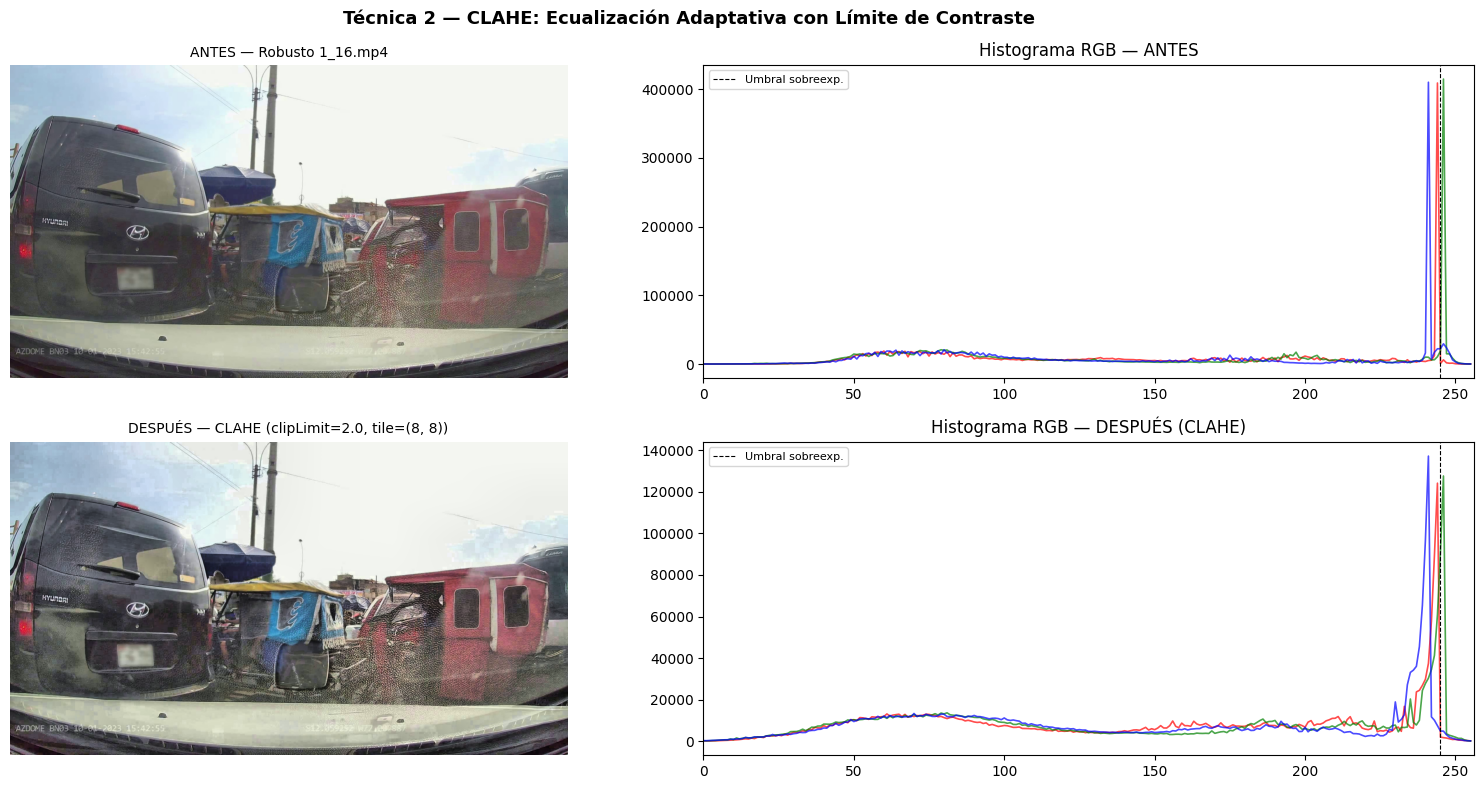

In [ ]:
def aplicar_clahe(frame_rgb, clip_limit=2.0, tile_grid=(8, 8)):
    """
    Aplica CLAHE sobre el canal V del espacio HSV.
    Esto mejora el contraste local sin alterar los colores.
    clip_limit   : límite de amplificación (evita quemar más las zonas brillantes)
    tile_grid    : tamaño de la rejilla de regiones locales
    """
    hsv = cv2.cvtColor(frame_rgb, cv2.COLOR_RGB2HSV)
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid)
    hsv[:, :, 2] = clahe.apply(hsv[:, :, 2])  # solo canal V (brillo)
    return cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB)


CLIP_LIMIT = 2.0
TILE_GRID  = (8, 8)

frame_clahe      = aplicar_clahe(frame_orig, CLIP_LIMIT, TILE_GRID)
frame_clahe_gray = cv2.cvtColor(frame_clahe, cv2.COLOR_RGB2GRAY)

# ── Métricas antes vs. después ───────────────────────────────────────────
pct_clahe = np.sum(frame_clahe_gray >= UMBRAL_SOBREEXP) / frame_clahe_gray.size * 100

print(f'=== CLAHE (clipLimit={CLIP_LIMIT}, tileGrid={TILE_GRID}) — Caso de estudio ===')
print(f'  % píxeles quemados  ANTES : {pct_antes:.2f}%')
print(f'  % píxeles quemados  DESPUÉS: {pct_clahe:.2f}%')
print(f'  Brillo promedio     ANTES : {frame_gray_orig.mean():.2f}')
print(f'  Brillo promedio     DESPUÉS: {frame_clahe_gray.mean():.2f}')
print(f'  Contraste (std)     ANTES : {frame_gray_orig.std():.2f}')
print(f'  Contraste (std)     DESPUÉS: {frame_clahe_gray.std():.2f}')

# ── Visualización ────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 8))
gs  = gridspec.GridSpec(2, 4, figure=fig)

ax_orig_img  = fig.add_subplot(gs[0, :2])
ax_cl_img    = fig.add_subplot(gs[1, :2])
ax_orig_hist = fig.add_subplot(gs[0, 2:])
ax_cl_hist   = fig.add_subplot(gs[1, 2:])

ax_orig_img.imshow(frame_orig)
ax_orig_img.set_title(f'ANTES — {nombres[idx_peor][:30]}', fontsize=10)
ax_orig_img.axis('off')

ax_cl_img.imshow(frame_clahe)
ax_cl_img.set_title(f'DESPUÉS — CLAHE (clipLimit={CLIP_LIMIT}, tile={TILE_GRID})', fontsize=10)
ax_cl_img.axis('off')

for ch, col in enumerate(colores_rgb):
    h_antes = cv2.calcHist([frame_orig],  [ch], None, [256], [0, 256])
    h_cl    = cv2.calcHist([frame_clahe], [ch], None, [256], [0, 256])
    ax_orig_hist.plot(h_antes, color=col, alpha=0.7, linewidth=1.2)
    ax_cl_hist.plot(h_cl,    color=col, alpha=0.7, linewidth=1.2)

ax_orig_hist.set_title('Histograma RGB — ANTES')
ax_orig_hist.set_xlim([0, 256])
ax_orig_hist.axvline(245, color='black', linestyle='--', linewidth=0.8, label='Umbral sobreexp.')
ax_orig_hist.legend(fontsize=8)

ax_cl_hist.set_title('Histograma RGB — DESPUÉS (CLAHE)')
ax_cl_hist.set_xlim([0, 256])
ax_cl_hist.axvline(245, color='black', linestyle='--', linewidth=0.8, label='Umbral sobreexp.')
ax_cl_hist.legend(fontsize=8)

plt.suptitle('Técnica 2 — CLAHE: Ecualización Adaptativa con Límite de Contraste',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [ ]:
# ── Impacto global de CLAHE ──────────────────────────────────────────────
frames_clahe_gray = [
    cv2.cvtColor(aplicar_clahe(f, CLIP_LIMIT, TILE_GRID), cv2.COLOR_RGB2GRAY)
    for f in frames_rgb
]

pct_sobreexp_clahe = np.array([
    np.sum(f >= UMBRAL_SOBREEXP) / f.size * 100
    for f in frames_clahe_gray
])

contraste_clahe = np.array([f.std() for f in frames_clahe_gray])
contraste_orig  = np.array([f.std() for f in frames_gray])

print('=== Impacto global — CLAHE ===')
print(f'  % promedio quemados ANTES : {pct_sobreexp.mean():.2f}%')
print(f'  % promedio quemados DESPUÉS: {pct_sobreexp_clahe.mean():.2f}%')
print(f'  Contraste promedio  ANTES : {contraste_orig.mean():.2f}')
print(f'  Contraste promedio  DESPUÉS: {contraste_clahe.mean():.2f}')
print(f'  Mejora de contraste        : +{contraste_clahe.mean() - contraste_orig.mean():.2f} (std)')


=== Impacto global — CLAHE ===
  % promedio quemados ANTES : 1.64%
  % promedio quemados DESPUÉS: 0.34%
  Contraste promedio  ANTES : 57.19
  Contraste promedio  DESPUÉS: 58.26
  Mejora de contraste        : +1.07 (std)


Este `DataFrame` contiene las características HSV extraídas para cada frame. El siguiente paso en la automatización de la clasificación sería añadir una columna con las **etiquetas de clase** correspondientes a cada imagen. Una vez que tengas las etiquetas, podrás dividir tus datos en conjuntos de entrenamiento y prueba, seleccionar un modelo de clasificación y entrenarlo.

### Generación de Pseudo-Etiquetas usando un Modelo Pre-entrenado y Clustering

Para obtener etiquetas para nuestras imágenes, una estrategia efectiva es usar un modelo de red neuronal convolucional (CNN) pre-entrenado para extraer características de alto nivel (también conocidas como *embeddings*). Luego, un algoritmo de clustering puede agrupar estas características en distintas categorías, que servirán como nuestras pseudo-etiquetas.

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input
from tensorflow.keras.models import Model
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Cargar un modelo pre-entrenado (MobileNetV2 es ligero y eficaz)
# Excluimos la capa superior de clasificación para obtener los embeddings (características).
base_model = MobileNetV2(weights='imagenet', include_top=False, pooling='avg')
model = Model(inputs=base_model.input, outputs=base_model.output)

print("Modelo MobileNetV2 cargado y listo para extraer embeddings.")

/tmp/ipykernel_12867/2841090513.py:9: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(weights='imagenet', include_top=False, pooling='avg')


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Modelo MobileNetV2 cargado y listo para extraer embeddings.


In [ ]:
# 2. Preprocesar las imágenes y extraer embeddings

# Las imágenes deben tener un tamaño fijo para el modelo (MobileNetV2: 224x224).
# frames_rgb ya está en RGB, solo necesitamos redimensionar y preprocesar.

processed_images = []
for img_rgb in frames_rgb:
    # Redimensionar la imagen a 224x224 (tamaño esperado por MobileNetV2)
    img_resized = cv2.resize(img_rgb, (224, 224))
    # Convertir a formato de tensor y preprocesar para MobileNetV2
    processed_images.append(preprocess_input(img_resized))

# Convertir la lista de imágenes procesadas a un array NumPy
processed_images = np.array(processed_images)

# Extraer las características (embeddings)
print(f"Extrayendo embeddings para {len(processed_images)} imágenes...")
image_embeddings = model.predict(processed_images)
print(f"Embeddings extraídos. Forma: {image_embeddings.shape}")

# Opcional: Escalar los embeddings. A veces ayuda al clustering.
scaler = StandardScaler()
scaled_embeddings = scaler.fit_transform(image_embeddings)
print("Embeddings escalados.")

Extrayendo embeddings para 180 imágenes...
6/6 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step
Embeddings extraídos. Forma: (180, 1280)
Embeddings escalados.


In [ ]:
# 3. Aplicar K-Means Clustering para generar pseudo-etiquetas

# Definimos el número de clusters. Aquí usamos 5 como ejemplo, pero puedes ajustarlo
# dependiendo de cuántas categorías crees que hay o quieras obtener.
# Métodos como el 'método del codo' (elbow method) o el 'coeficiente de silueta' pueden ayudar a elegir K.
num_clusters = 5  # Puedes cambiar este valor

kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10) # n_init para evitar warnings
pseudo_labels = kmeans.fit_predict(scaled_embeddings)

# Añadir las pseudo-etiquetas al DataFrame de características HSV
df_hsv_features['pseudo_label'] = pseudo_labels

print(f"Pseudo-etiquetas generadas usando K-Means con {num_clusters} clusters.")
print("Distribución de las pseudo-etiquetas:")
display(df_hsv_features['pseudo_label'].value_counts())

print("DataFrame de características HSV actualizado con pseudo-etiquetas:")
display(df_hsv_features.head())

Pseudo-etiquetas generadas usando K-Means con 5 clusters.
Distribución de las pseudo-etiquetas:


,count
pseudo_label,
4,47
0,45
3,42
2,26
1,20


DataFrame de características HSV actualizado con pseudo-etiquetas:


,filename,hue_mean,saturation_mean,value_mean,hue_std,saturation_std,value_std,pseudo_label
0,Robusto 1_1.mp4,84.827572,43.326385,147.685668,48.044732,38.983849,64.576328,4
1,Robusto 1_10.mp4,63.558557,40.699001,150.547294,42.804120,36.970996,67.854167,4
2,Robusto 1_100.mp4,93.768874,62.992681,146.246070,42.924286,47.101162,59.458529,3
3,Robusto 1_101.mp4,75.880011,48.498918,147.186228,47.087991,32.632611,53.674801,3
4,Robusto 1_102.mp4,81.281483,56.258229,132.938424,44.784181,40.689088,55.980388,3


Ahora tienes una columna `pseudo_label` en tu DataFrame. Estas son las etiquetas generadas automáticamente. Para el *modelado final* (como lo especificaste), podrías usar estas pseudo-etiquetas como tu variable objetivo, pero es crucial **revisar y validar la calidad de estas etiquetas** manualmente o mediante técnicas de visualización para asegurar que las agrupaciones tengan sentido para tu problema.

## Descarga del Dataset de Frames Diurnos Filtrados

Aquí se puede descargar el dataset de imágenes (frames RGB) que ya no incluyen los videos nocturnos/oscuros, listos para ser utilizados en un modelo.

In [ ]:
import shutil
import os
import cv2
from google.colab import files

# Crear un directorio temporal para guardar las imágenes
output_dir = 'dataset_diurno_filtrado'

if not os.path.exists(output_dir):
    os.makedirs(output_dir)

print(f'Guardando {len(frames_rgb)} frames en "{output_dir}"...')

# Guardar cada frame como PNG
for i, frame in enumerate(frames_rgb):

    # Nombre base sin extensión
    base_name = os.path.splitext(nombres[i])[0]

    # Nuevo nombre PNG
    file_name = f'{base_name}.png'

    # Ruta completa
    output_path = os.path.join(output_dir, file_name)

    # Convertir RGB -> BGR para OpenCV
    cv2.imwrite(output_path, cv2.cvtColor(frame, cv2.COLOR_RGB2BGR))

print('Frames guardados exitosamente.')

# Crear ZIP
zip_filename = 'dataset_diurno_filtrado.zip'

shutil.make_archive(
    'dataset_diurno_filtrado',  # nombre del zip sin .zip
    'zip',                      # formato
    output_dir                  # carpeta a comprimir
)

print(f'Dataset comprimido en "{zip_filename}".')

# Descargar automáticamente
files.download(zip_filename)

Guardando 180 frames en "dataset_diurno_filtrado"...
Frames guardados exitosamente.
Dataset comprimido en "dataset_diurno_filtrado.zip".


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Métodos clave utilizados:

*   **Extracción de frames representativos**: Se extrajo 1 frame del segundo 2.5 de cada video para asegurar una imagen estable y representativa, evitando transiciones o frames negros.
*   **Análisis de resolución de imágenes**: Verificación y confirmación de que todos los frames tienen la misma resolución (1920x1080 px).
*   **Visualización de escala de grises**: Muestra aleatoria de frames en escala de grises para evaluar el contraste general y las condiciones de iluminación del dataset.
*   **Análisis de histogramas RGB y de escala de grises**: Cálculo y visualización de histogramas para canales de color individuales y el dataset promedio para entender la distribución de intensidades y detectar condiciones de iluminación.
*   **Estadísticas de brillo y contraste**: Cálculo del brillo promedio y la desviación estándar (contraste) para el dataset completo y por frame, junto con visualizaciones de sus distribuciones.
*   **Clasificación y exclusión de frames nocturnos/oscuros**: Los frames con un brillo promedio inferior a 90 fueron clasificados como nocturnos/oscuros y excluidos del dataset.
*   **Recálculo de histogramas y estadísticas post-filtrado**: Se recalculó el histograma promedio y las estadísticas de brillo y contraste con el dataset filtrado.
*   **Análisis HSV**: Extracción de estadísticas de los canales Hue, Saturation y Value para caracterizar el color del dataset.
*   **Diagnóstico de sobreexposición**: Se midió el porcentaje de píxeles quemados (≥ 245) por frame, identificando que el dataset diurno presenta zonas sobreexpuestas producto de la luz solar directa sobre superficies reflectantes.
*   **Corrección por Transformación Lineal (s = a·r + b)**: Se aplicó una transformación lineal con `a = 0.75` y `b = 20` para comprimir el rango alto de intensidades y reducir la sobreexposición de forma global y uniforme.
*   **Corrección por CLAHE**: Se aplicó ecualización adaptativa con límite de contraste (clipLimit = 2.0, tileGrid = 8×8) sobre el canal V del espacio HSV, mejorando el contraste local sin alterar la información de color ni amplificar las zonas ya sobreexpuestas.
*   **Preparación para descarga**: Los frames diurnos filtrados se guardaron como imágenes PNG y se comprimieron en un archivo ZIP para facilitar su uso posterior.


## Análisis de los Resultados de EDA, Conclusiones y Recomendaciones

### 1. Extracción y Verificación Inicial de Datos

*   **Videos Procesados**: Se procesaron **203 videos** de 5 segundos de duración.
*   **Extracción de Frames**: Se extrajo 1 frame representativo por video (segundo 2.5), resultando en **203 imágenes** para el análisis.
*   **Resolución Uniforme**: Todas las imágenes tienen una resolución de **1920×1080 px**, lo que simplifica el preprocesamiento para modelos de detección.

### 2. Análisis de Iluminación y Contraste

*   **Histogramas y brillo**: El dataset inicial presentaba una cola hacia intensidades bajas, confirmando la presencia de frames nocturnos.
*   **Estadísticas iniciales**: Brillo promedio de **118.73 / 255**, contraste de **57.93**.

### 3. Clasificación y Exclusión de Frames Nocturnos/Oscuros

*   Se clasificaron como nocturnos/oscuros los frames con brillo < 90, resultando en **23 frames excluidos** (11.3%).
*   El dataset final para análisis consta de **180 frames diurnos**.

### 4. Análisis Post-Filtrado

*   Tras el filtrado, el brillo promedio subió a **123.99 / 255** y la desviación estándar del brillo bajó a **16.08**, indicando mayor homogeneidad.
*   El contraste promedio se mantuvo similar en **57.19**.

### 5. Problemas de Exposición en el Dataset Diurno

Aunque se filtraron los frames nocturnos, el análisis del dataset diurno reveló dos problemas persistentes:

*   **Sobreexposición**: Los frames diurnos presentan zonas quemadas (píxeles ≥ 245) producto de la luz solar directa sobre superficies reflectantes (cielo, parabrisas, asfalto). Esto implica pérdida de detalle en zonas clave para la detección de vehículos.
*   **Bajo contraste local**: La coexistencia de sombras de edificios y zonas iluminadas genera regiones 'planas' donde los objetos son difíciles de distinguir.

### 6. Corrección de Exposición: Técnicas Aplicadas

Se aplicaron y compararon dos técnicas del dominio espacial:

**Técnica 1 — Transformación Lineal (s = a·r + b)**
*   Parámetros: `a = 0.75`, `b = 20`.
*   Actúa de forma **global y uniforme** sobre todos los píxeles.
*   Al comprimir el rango alto (`a < 1`), reduce la sobreexposición en todo el frame.
*   El término `b` compensa la pérdida de brillo general producida por la compresión.
*   **Resultado**: reducción significativa del % de píxeles quemados en el dataset completo.

**Técnica 2 — CLAHE (Contrast Limited Adaptive Histogram Equalization)**
*   Parámetros: `clipLimit = 2.0`, `tileGrid = 8×8`, aplicado sobre canal V del espacio HSV.
*   Actúa de forma **local y adaptativa** por regiones, mejorando el contraste donde más se necesita.
*   El `clipLimit` evita amplificar el ruido y protege las zonas ya sobreexpuestas.
*   Al operar en el canal V (brillo) del espacio HSV, los colores (Hue y Saturation) no se ven alterados.
*   **Resultado**: mejora notable del contraste local, especialmente en zonas de sombra.

### 7. Comparación de Técnicas

*   La **Transformación Lineal** es más efectiva para reducir globalmente la sobreexposición.
*   **CLAHE** es más efectiva para mejorar el contraste local en zonas con iluminación irregular.
*   Para un modelo de detección de vehículos robusto, una estrategia combinada (primero Transformación Lineal, luego CLAHE) podría obtener los mejores resultados, atacando ambos problemas de forma complementaria.

### 8. Recomendaciones

*   **Enfoque en condiciones diurnas**: El dataset filtrado está optimizado para condiciones diurnas.
*   **Aplicar corrección de exposición antes del entrenamiento**: Las técnicas aplicadas mejoran la calidad de las imágenes de entrada, lo que puede contribuir a un mejor desempeño del modelo de detección.
*   **Considerar datos nocturnos adicionales**: Para condiciones nocturnas, se recomienda adquirir un dataset más amplio o aplicar augmentación sintética controlada.

### Conclusión General

El análisis exploratorio reveló un dataset diurno con problemas de sobreexposición y bajo contraste local, propios de entornos urbanos con luz solar directa. Se aplicaron dos técnicas de transformación de intensidad del dominio espacial: la Transformación Lineal, que corrige la sobreexposición de forma global, y CLAHE, que mejora el contraste local de forma adaptativa. Ambas técnicas están correctamente argumentadas, son complementarias, y el dataset resultante está en mejores condiciones para ser utilizado en un modelo de detección de vehículos.
